In [3]:
import pandas as pd
import numpy as np
data_toxic = pd.read_csv("traslated_data_train.csv")
data_toxic.head()

,Unnamed: 0,comment_number,comment_sentence
0,0,0,(1 (1 (2 explanation.why) (1 (2 (2 the) (3 edi...
1,1,0,(1 (2 they) (1 (1 (2 (2 weren) (2 (2 (2 t) (2 ...
2,2,0,(2 (2 and) (2 (2 (2 please) (2 (2 (2 don) (2 (...
3,3,0,(2 .)
4,4,0,(2 .)


In [3]:
data_toxic.shape

(709054, 3)

In [4]:
data_toxic.tail()

,Unnamed: 0,comment_number,comment_sentence
709049,709049,159499,(2 (2 (2 call) (2 (3 me) (2 (2 vandal) (2 (2 (...
709050,709050,159499,(3 (2 i) (3 (3 (2 wish) (3 (2 you) (3 well))) ...
709051,709051,159499,(2 .)
709052,709052,159499,(2 .)
709053,709053,159499,(2 .)


In [6]:
709054 / 159500 # mean number of sentences in each comment

4.445479623824451

In [7]:
#visualize the distribution

In [8]:
len_sentences = []
comment_number = 0
length = 0
for i in range(709053):
    if length == 0:
        length = 1
    elif data_toxic.iloc[i, 1] == comment_number:
        length += 1
    elif data_toxic.iloc[i, 1] > comment_number:
        len_sentences.append(length)
        length = 1
        comment_number += 1
       

In [9]:
len(len_sentences)

159499

In [10]:
import matplotlib.pyplot as plt

(array([35809., 32142., 25065., 18222., 13048.,  8826.,  6324.,  4388.,
         2992.,  2158.,  1645.,  1263.,  1871.]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 <a list of 13 Patch objects>)

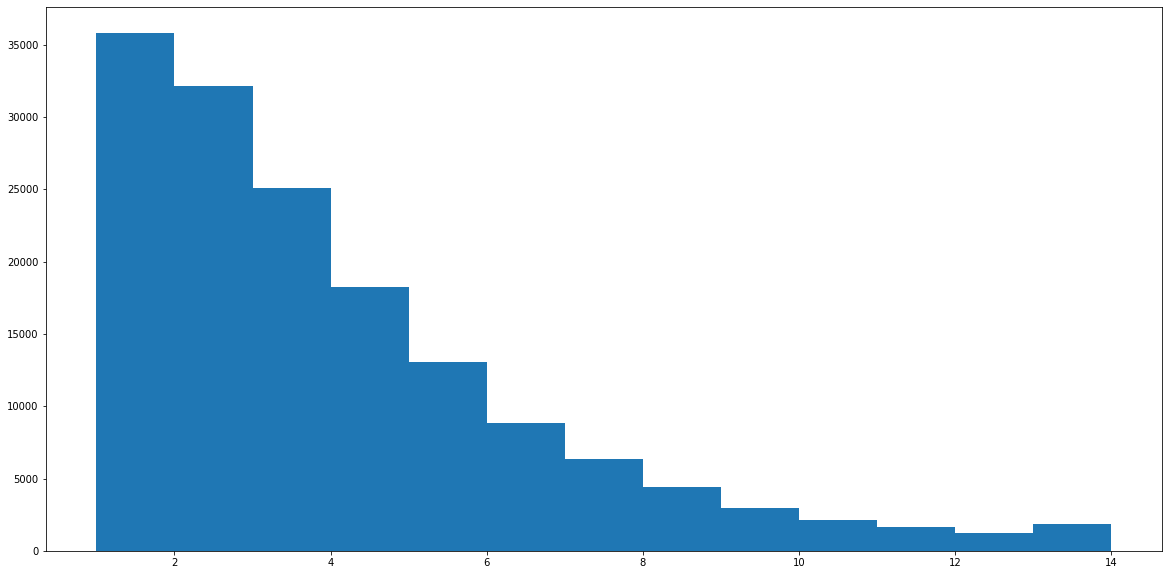

In [11]:
plt.figure(figsize=(20,10))
plt.hist(len_sentences, bins=[1,2,3,4,5,6,7,8,9,10,11,12,13,14])

In [12]:
data_toxic["comment_number"].value_counts()

4712      682
53530     499
56154     439
46197     385
158970    358
         ... 
3311        1
18524       1
120158      1
30810       1
62123       1
Name: comment_number, Length: 159498, dtype: int64

In [13]:
import statistics

In [14]:
statistics.stdev(len_sentences) # standard deviation

6.928426716876806

In [15]:
statistics.mean(len_sentences) # mean

4.445438529395169

In [18]:
np.percentile(len_sentences, 95) # we will use 95% of the data if we take 12 as a standard length

12.0

In [19]:
np.percentile(len_sentences, 75)# is that a good option, 75%??

5.0

In [20]:
np.percentile(len_sentences, 20)

1.0

The decision is to limit each comment by 5 first sentences.

In [1]:
from copy import deepcopy

In [ ]:
# Since I decided to use only 5 first sentences from each comment, I will delete the rest
new_data_toxic = deepcopy(data_toxic) # make a copy

comment_len = len(len_sentences)

for i in range(comment_len):
    comment = new_data_toxic[new_data_toxic["comment_number"] == i]
    if comment.shape[0] > 5:
        indexes = comment.iloc[5:, 0].values
        print(indexes)
        new_data_toxic = new_data_toxic.drop(labels=indexes, axis=0)
        

In [ ]:
new_data_toxic.to_csv("translated_data_train_5_sentences.csv")

In [5]:
#the same for test data
data_toxic_test = pd.read_csv("translated_data_test.csv")
data_toxic_test.tail()

,Unnamed: 0,comment_number,comment_sentence
751001,751001,153162,(1 (2 (2 israel) (2 (2 by) (2 contrast))) (1 (...
751002,751002,153163,(2 .)
751003,751003,153163,(2 (2 (2 stop) (2 already)) (2 .))
751004,751004,153163,(1 (2 (2 your) (2 bullshit)) (1 (1 (1 (1 (2 is...
751005,751005,153163,(1 (1 (2 i) (1 (1 (1 (2 m) (1 (1 no) (1 fool))...


In [ ]:
new_data_toxic = deepcopy(data_toxic_test)

comment_len = 153164

for i in range(comment_len):
    comment = new_data_toxic[new_data_toxic["comment_number"] == i]
    if comment.shape[0] > 5:
        indexes = comment.iloc[5:, 0].values
        print(indexes)
        new_data_toxic = new_data_toxic.drop(labels=indexes, axis=0)

In [ ]:
new_data_toxic.to_csv("translated_data_test_5_sentences.csv")